# Fase 4 — Detecção de Anomalias: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Quais candidatos têm combinações atípicas de idade, escolaridade e patrimônio declarado, em relação à base inteira ou ao próprio perfil da Fase 2?**

Reutilizamos o recorte **Deputado Federal / Centro-Oeste** e os seis clusters nomeados do Bisecting K-Means da Fase 2. Treinamos **Isolation Forest** em dois níveis:

1. **Global:** compara cada candidato com todos os candidatos da base preparada.
2. **Dentro do cluster:** compara cada candidato somente com os integrantes do seu grupo.

Um candidato pode ser típico globalmente e atípico dentro do seu grupo. A análise produz uma lista para examinar, não uma classificação de irregularidade. Não há rótulos conhecidos de anomalia para medir acurácia; os resultados dependem das variáveis, da base e do limiar escolhido.


## Configuração

Use os **mesmos valores** que você usou nas Fases 0/1/2/3.


In [1]:
CARGO = "DEPUTADO FEDERAL"  # mesmo valor usado nas Fases 0/1/2
UF = ["DF", "GO", "MT", "MS"]  # mesmo valor usado nas Fases 0/1/2
ANO_ELEICAO = 2026

## Preparando a base — reconstituindo os seis clusters nomeados da Fase 2

Usamos a mesma preparação das Fases 2 e 3: escolaridade em anos equivalentes, corte superior de patrimônio por IQR em `Total_Bens_Log` e `MinMaxScaler` nas três variáveis-driver. Reconstituímos **Bisecting K-Means com k=6, inércia total, semente 42 e n_init=10**, atribuindo letras por tamanho e os mesmos nomes.

A análise global se refere à **base preparada**. Registros excluídos pelo filtro de patrimônio ou por escolaridade desconhecida não receberão score aqui; a tabela de exclusões permite verificar esse recorte antes de interpretar os resultados. O filtro é mantido para comparar as fases.


In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from IPython.display import display
import plotly.graph_objects as go

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option(
    "display.max_colwidth", None
)  # não truncar antecedents/consequents nas tabelas

SEMENTE = 42
np.random.seed(
    SEMENTE
)  # mesmo racional de reprodutibilidade defensiva dos notebooks anteriores

nome_uf = (
    UF
    if isinstance(UF, str)
    else (
        "CENTRO_OESTE"
        if UF and set(UF) == {"DF", "GO", "MT", "MS"}
        else "_".join(sorted(UF)) if UF else "BRASIL"
    )
)
nome_cargo = CARGO.replace(" ", "_")
# Ajuste o nome do arquivo conforme o gerado pelo 00_preparacao_dados.ipynb
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_CENTRO_OESTE_2026.csv  ->  692 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532001,3022,ALESSANDRA ALMEIDA CHIANELLI DUTRA,ALE CHIANELLI,#NULO,58442472134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,DF,1972-11-28,11236642070,4,FEMININO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,130000.0,0.0,0.0,0.0,0.0,130000.0,11.775297,53
1,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532002,3012,PAULO CESAR ECHEBARRIA DE CARVALHO,PAULO ECHEBARRIA,#NULO,37959077134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1965-10-20,7033782089,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,380000.0,0.0,0.0,0.0,15000000.0,15380000.0,16.548579,60
2,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532003,3004,FLAVIO HENRIQUE TORMINN FLEURY,FLAVIO FLEURY,#NULO,88847560144,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1981-09-01,46935651074,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,114,FISIOTERAPEUTA E TERAPEUTA OCUPACIONAL,-1,#NULO,0.0,53000.0,0.0,0.0,0.0,0.0,53000.0,10.878066,45
3,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532004,3030,CARINE TEIXEIRA MARQUES,CARINE TEIXEIRA,#NULO,1642767182,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1986-08-25,52572671066,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,257,EMPRESÁRIO,-1,#NULO,0.0,0.0,0.0,0.0,120000.0,0.0,120000.0,11.695255,40
4,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532005,3010,EMILIO KERBER FILHO,EMILIO KERBER,#NULO,92759130053,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,PR,1976-08-31,263044410167,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,185,ESCRITOR E CRÍTICO,-1,#NULO,1380000.0,0.0,0.0,0.0,0.0,0.0,1380000.0,14.137595,50


In [3]:
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — mesma decisão da Versão 2 do notebook de clusterização
}

df["ANOS_ESTUDO"] = df["DS_GRAU_INSTRUCAO"].map(ANOS_ESTUDO_POR_GRAU)

In [4]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']

Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
limite_superior = Q3 + 1.5 * (Q3 - Q1)
mask_base = (df['Total_Bens_Log'] <= limite_superior) & df['ANOS_ESTUDO'].notna()
excluidos_preparacao = df.loc[~mask_base, [
    'SQ_CANDIDATO', 'NM_URNA_CANDIDATO', 'IDADE', 'DS_GRAU_INSTRUCAO', 'Total_Bens',
]].copy()
df_cluster = df.loc[mask_base].copy().reset_index(drop=True)

if len(df_cluster) < 6:
    raise ValueError('A base precisa ter pelo menos seis candidatos para reproduzir os clusters.')
if not np.isfinite(df_cluster[colunas_driver].to_numpy()).all():
    raise ValueError('Há valores ausentes ou infinitos nas variáveis-driver. Revise a Fase 0.')

print(f'Base preparada: {len(df_cluster)} de {len(df)} candidatos; excluídos: {len(excluidos_preparacao)}')
display(excluidos_preparacao)
scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])


Base preparada: 692 de 692 candidatos; excluídos: 0


,SQ_CANDIDATO,NM_URNA_CANDIDATO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens


In [5]:
def bisecting_kmeans_ate_k(X, k_max, criterio="inercia", random_state=SEMENTE):
    """Reproduz as divisões da Parte 2 da Fase 2 e devolve a partição final."""

    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum())

    clusters = {0: np.arange(X.shape[0])}
    proximo_id = 1
    for _ in range(1, k_max):
        if criterio == "tamanho":
            id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        elif criterio == "inercia":
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))
        else:
            raise ValueError("criterio deve ser 'tamanho' ou 'inercia'")
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break
        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2
        del clusters[id_escolhido]
        clusters[id_a] = indices_pai[labels2 == 0]
        clusters[id_b] = indices_pai[labels2 == 1]
    return clusters


k_bisecting = 6  # mesmo k escolhido no 02_clusterizacao.ipynb (Parte 2)

criterio_bisecting = "inercia"  # mesma execução da Parte 2 da Fase 2
clusters_finais = bisecting_kmeans_ate_k(X, k_bisecting, criterio=criterio_bisecting)
ids_por_tamanho = sorted(
    clusters_finais, key=lambda cid: len(clusters_finais[cid]), reverse=True
)

rotulos = np.empty(X.shape[0], dtype=object)
for letra, cid in zip(
    [chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho
):
    rotulos[clusters_finais[cid]] = letra
df_cluster["cluster_bisecting"] = rotulos

# Mesmos nomes usados na Parte 2 da Fase 2.
NOMES_CLUSTER_BISECTING = {
    "A": "Adultos com superior e bens",
    "B": "Mais velhos com superior e bens",
    "C": "Alta escolaridade sem bens declarados",
    "D": "Jovens com menor escolaridade e poucos bens",
    "E": "Adultos com escolaridade intermediária e bens",
    "F": "Mais velhos com menor escolaridade e bens",
}
df_cluster["cluster"] = df_cluster["cluster_bisecting"].map(NOMES_CLUSTER_BISECTING)

if df_cluster["cluster"].isna().any():
    raise ValueError("Há clusters sem nome. Revise NOMES_CLUSTER_BISECTING.")

resumo_clusters = (
    df_cluster.groupby("cluster_bisecting")
    .agg(
        qtd_candidatos=("SQ_CANDIDATO", "count"),
        idade_media=("IDADE", "mean"),
        anos_estudo_medio=("ANOS_ESTUDO", "mean"),
        patrimonio_mediano=("Total_Bens", "median"),
    )
    .round(1)
)
resumo_clusters.insert(0, "nome", resumo_clusters.index.map(NOMES_CLUSTER_BISECTING))
display(resumo_clusters)

,nome,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster_bisecting,,,,,
A,Adultos com superior e bens,203,42.4,16.0,495000.0
B,Mais velhos com superior e bens,184,61.6,15.8,895668.0
C,Alta escolaridade sem bens declarados,106,49.5,14.8,0.0
D,Jovens com menor escolaridade e poucos bens,90,36.7,9.7,0.0
E,Adultos com escolaridade intermediária e bens,75,40.4,11.2,217000.0
F,Mais velhos com menor escolaridade e bens,34,61.3,9.5,496103.9


## Isolation Forest: como funciona

O algoritmo cria árvores com cortes aleatórios nas variáveis. Combinações incomuns tendem a alcançar folhas em caminhos mais curtos; os caminhos são agregados sobre muitas árvores. As árvores têm limite de profundidade, e folhas podem conter vários registros: o score considera essa situação.

Neste notebook:

- `predict`: **-1 = Atípico**, **1 = Típico**, segundo o limiar do modelo.
- `decision_function`: valores **menores indicam maior atipicidade**; negativos ficam do lado atípico do limiar. Não é uma probabilidade.
- `contamination=0.05`: define um limiar para sinalizar aproximadamente 5% dos registros usados no treinamento; não estima a proporção verdadeira de anomalias. Empates nos scores podem alterar a quantidade.
- `contamination='auto'`: usa o limiar padrão da implementação, sem fixar uma porcentagem.

Usamos 200 árvores e semente 42. Consulte a [documentação do Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html).

### Demonstração com dados fictícios

Geramos dois grupos concentrados e pontos uniformemente espalhados. Sabemos quais foram gerados de cada forma, mas pontos espalhados podem cair perto dos grupos; o rótulo de geração não garante que sejam geometricamente atípicos.


In [6]:
rng = np.random.default_rng(SEMENTE)

# "normal": dois grupos bem comportados (como se fossem 2 clusters)
normal_1 = rng.normal(loc=[2, 2], scale=0.6, size=(80, 2))
normal_2 = rng.normal(loc=[6, 6], scale=0.6, size=(80, 2))
X_normal_ficticio = np.vstack([normal_1, normal_2])

# Pontos espalhados: alguns podem cair perto dos grupos.
X_anomalo_ficticio = rng.uniform(low=-2, high=10, size=(12, 2))

X_ficticio = np.vstack([X_normal_ficticio, X_anomalo_ficticio])
rotulo_real_ficticio = np.array(['Normal'] * len(X_normal_ficticio) + ['Anômalo (fictício)'] * len(X_anomalo_ficticio))

# contamination = a fração real de anômalos fictícios (aqui podemos "trapacear" porque sabemos)
iso_ficticio = IsolationForest(contamination=len(X_anomalo_ficticio) / len(X_ficticio),
                                random_state=SEMENTE, n_estimators=200)
pred_ficticio = iso_ficticio.fit_predict(X_ficticio)
score_ficticio = iso_ficticio.decision_function(X_ficticio)

print(f"Score médio — Normal: {score_ficticio[rotulo_real_ficticio == 'Normal'].mean():.3f}  |  "
      f"Anômalo: {score_ficticio[rotulo_real_ficticio == 'Anômalo (fictício)'].mean():.3f}")


Score médio — Normal: 0.132  |  Anômalo: -0.092


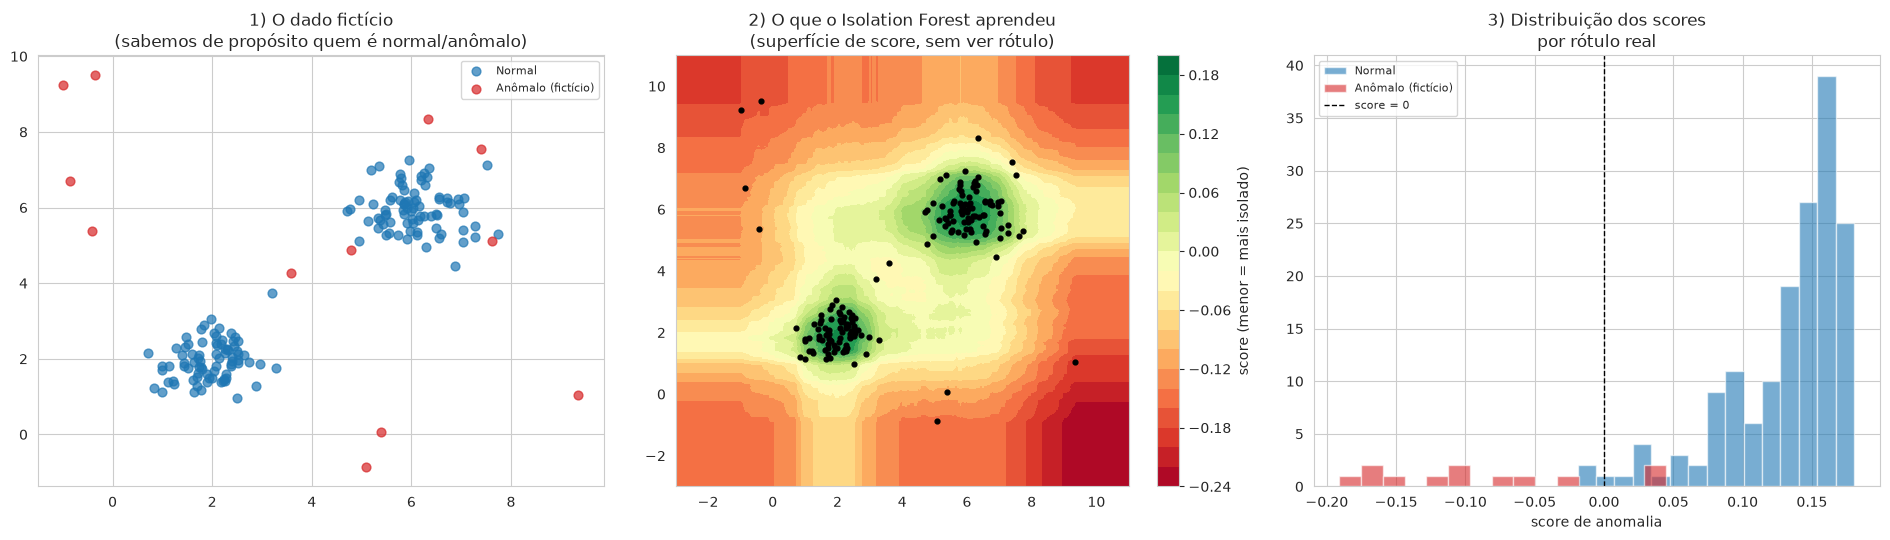

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

cores_ficticio = {'Normal': 'tab:blue', 'Anômalo (fictício)': 'tab:red'}
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[0].scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, label=rotulo, alpha=0.7, s=40)
axes[0].set_title('1) O dado fictício\n(sabemos de propósito quem é normal/anômalo)')
axes[0].legend(fontsize=8)

# superfície de score: o que o algoritmo "enxerga", sem ver rótulo nenhum
xx, yy = np.meshgrid(np.linspace(-3, 11, 300), np.linspace(-3, 11, 300))
Z = iso_ficticio.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cs = axes[1].contourf(xx, yy, Z, levels=20, cmap='RdYlGn')
axes[1].scatter(X_ficticio[:, 0], X_ficticio[:, 1], c='black', s=12)
plt.colorbar(cs, ax=axes[1], label='score (menor = mais isolado)')
axes[1].set_title('2) O que o Isolation Forest aprendeu\n(superfície de score, sem ver rótulo)')

# distribuição dos scores por rótulo real
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[2].hist(score_ficticio[m], bins=15, color=cor, alpha=0.6, label=rotulo)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='score = 0')
axes[2].set_title('3) Distribuição dos scores\npor rótulo real')
axes[2].set_xlabel('score de anomalia')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


A superfície mostra o score do modelo: regiões com valores menores são mais atípicas segundo a floresta. O histograma compara os scores dos dois mecanismos de geração. Pode haver sobreposição, pois pontos uniformes podem cair perto dos grupos concentrados. O modelo não recebeu os rótulos de geração.


### Por dentro de uma única árvore

Desenhamos os primeiros cortes de uma árvore e comparamos a profundidade até a folha para dois pontos. A profundidade varia entre árvores; a floresta agrega seus resultados. Esse gráfico é uma ilustração do mecanismo, não o score completo: uma folha pode conter vários registros, exigindo uma correção no comprimento do caminho.


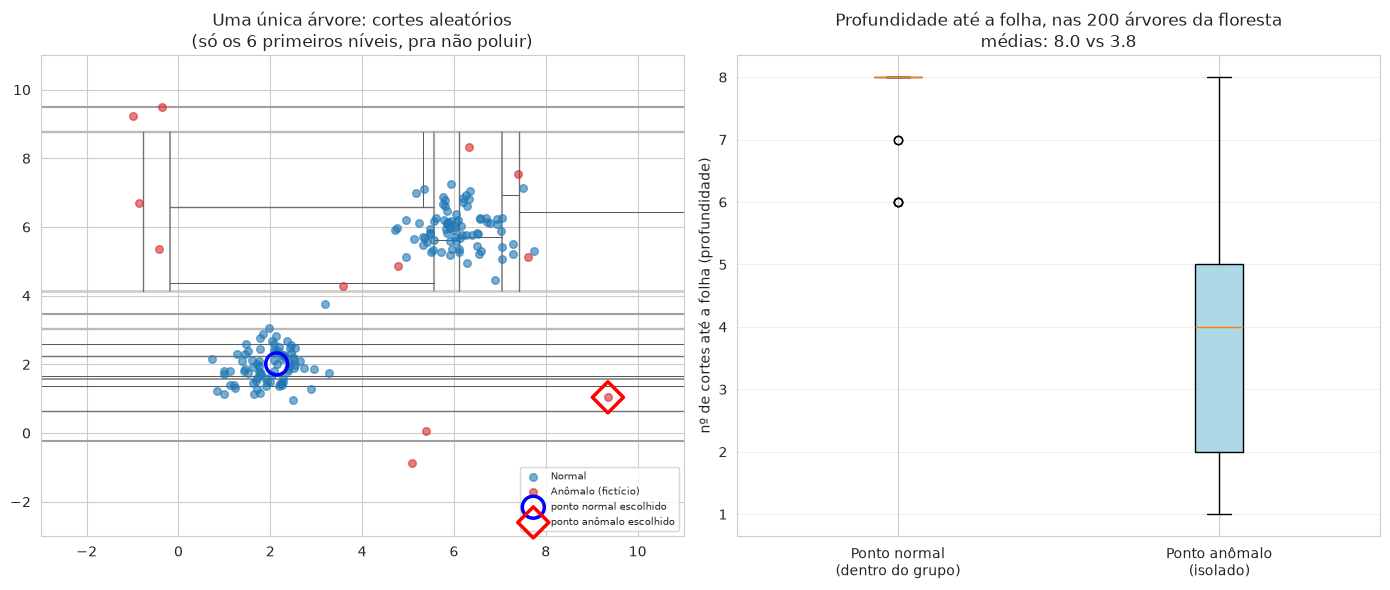

In [8]:
def desenhar_particoes(ax, tree_, no, x_min, x_max, y_min, y_max, profundidade=0, profundidade_max=6):
    """Desenha recursivamente os cortes de uma árvore de isolamento dentro de uma caixa
    [x_min,x_max] x [y_min,y_max]. Só os primeiros `profundidade_max` níveis são desenhados —
    a árvore também tem limite de profundidade e pode terminar com vários pontos
    na mesma folha."""
    if profundidade >= profundidade_max or tree_.children_left[no] == -1:  # -1 = folha
        return
    variavel, limiar = tree_.feature[no], tree_.threshold[no]
    cor = plt.cm.Greys(0.3 + 0.5 * profundidade / profundidade_max)
    espessura = max(2 - 0.25 * profundidade, 0.4)
    if variavel == 0:
        ax.plot([limiar, limiar], [y_min, y_max], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, limiar, y_min, y_max, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], limiar, x_max, y_min, y_max, profundidade + 1, profundidade_max)
    else:
        ax.plot([x_min, x_max], [limiar, limiar], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, x_max, y_min, limiar, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], x_min, x_max, limiar, y_max, profundidade + 1, profundidade_max)


def profundidade_isolamento(tree_, ponto):
    """Quantos cortes levam `ponto` até sua folha, que pode conter vários registros."""
    no, profundidade = 0, 0
    while tree_.children_left[no] != -1:
        variavel, limiar = tree_.feature[no], tree_.threshold[no]
        no = tree_.children_left[no] if ponto[variavel] <= limiar else tree_.children_right[no]
        profundidade += 1
    return profundidade


# dois pontos escolhidos de propósito: o mais "normal" (mais perto do centro do 1º grupo) e o
# mais "anômalo" de verdade segundo o próprio modelo (menor score entre os pontos fictícios)
ponto_normal = X_normal_ficticio[np.argmin(np.linalg.norm(X_normal_ficticio - [2, 2], axis=1))]
scores_dos_anomalos = iso_ficticio.decision_function(X_anomalo_ficticio)
ponto_anomalo = X_anomalo_ficticio[np.argmin(scores_dos_anomalos)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# painel A: uma única árvore da floresta, cortes desenhados
ax = axes[0]
x_min, x_max, y_min, y_max = -3, 11, -3, 11
uma_arvore = iso_ficticio.estimators_[0].tree_
desenhar_particoes(ax, uma_arvore, 0, x_min, x_max, y_min, y_max)
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    ax.scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, alpha=0.6, s=30, label=rotulo, zorder=3)
ax.scatter(*ponto_normal, s=250, facecolor='none', edgecolor='blue', linewidth=2.5, zorder=4, label='ponto normal escolhido')
ax.scatter(*ponto_anomalo, s=250, facecolor='none', edgecolor='red', linewidth=2.5, marker='D', zorder=4, label='ponto anômalo escolhido')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Uma única árvore: cortes aleatórios\n(só os 6 primeiros níveis, pra não poluir)')
ax.legend(fontsize=7, loc='lower right')

# painel B: profundidade até isolar cada um dos 2 pontos, em TODAS as árvores da floresta
profundidades_normal = [profundidade_isolamento(arv.tree_, ponto_normal) for arv in iso_ficticio.estimators_]
profundidades_anomalo = [profundidade_isolamento(arv.tree_, ponto_anomalo) for arv in iso_ficticio.estimators_]

ax2 = axes[1]
ax2.boxplot([profundidades_normal, profundidades_anomalo],
            tick_labels=['Ponto normal\n(dentro do grupo)', 'Ponto anômalo\n(isolado)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.set_ylabel('nº de cortes até a folha (profundidade)')
ax2.set_title(f'Profundidade até a folha, nas {len(iso_ficticio.estimators_)} árvores da floresta\n'
              f'médias: {np.mean(profundidades_normal):.1f} vs {np.mean(profundidades_anomalo):.1f}')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Compare os caminhos dos dois pontos na floresta. Caminhos mais curtos tendem a indicar combinações mais fáceis de separar. Uma árvore isolada pode dar um resultado diferente das outras; o modelo combina todas. As linhas no painel de cortes ilustram partições, não fronteiras definitivas de anomalia.


---
## Detecção global: quem foge do padrão geral da base?

Reaproveitamos exatamente as mesmas 3 variáveis-driver já padronizadas na Fase 2 (`X`: `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`) — mesma pergunta de negócio, agora olhando pra quem está nas bordas em vez de procurar grupos.

Antes de fixar `contamination`, vale ver como o número de candidatos sinalizados muda conforme a suposição:


,contamination,qtd_atipicos,pct_atipicos
0,0.02,14,2.0
1,0.03,21,3.0
2,0.05,35,5.1
3,0.08,56,8.1
4,auto,225,32.5


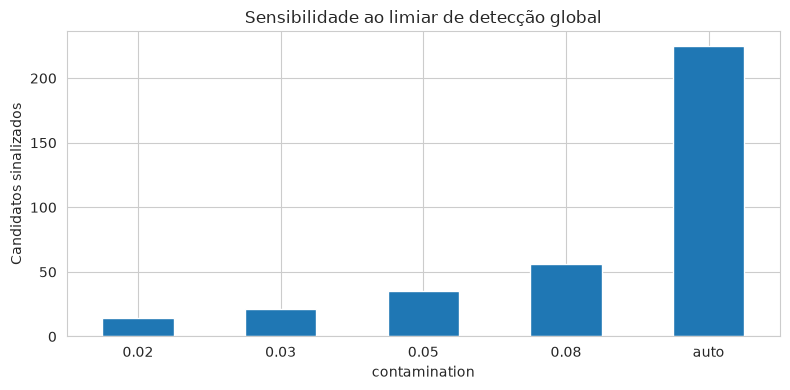

In [9]:
sensibilidade = []
for cont in [0.02, 0.03, 0.05, 0.08, 'auto']:
    modelo = IsolationForest(contamination=cont, random_state=SEMENTE, n_estimators=200)
    pred = modelo.fit_predict(X)
    sensibilidade.append({
        'contamination': str(cont),
        'qtd_atipicos': int((pred == -1).sum()),
        'pct_atipicos': round((pred == -1).mean() * 100, 1),
    })
sensibilidade = pd.DataFrame(sensibilidade)
display(sensibilidade)
sensibilidade.plot.bar(x='contamination', y='qtd_atipicos', legend=False, figsize=(8, 4))
plt.ylabel('Candidatos sinalizados')
plt.title('Sensibilidade ao limiar de detecção global')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Escolhemos **5% como um orçamento inicial de revisão**, não como taxa real de anomalias. A tabela mostra a sensibilidade da quantidade ao limiar; os valores numéricos de `contamination` ajustam o corte dos scores. Reavalie a lista com outros limiares antes de escolher casos para examinar. O modo `auto` também precisa de interpretação, não é uma resposta automaticamente melhor.


In [10]:
contamination_global = 0.05  # ajuste conforme a célula anterior, se quiser um recorte maior/menor

iso_global = IsolationForest(contamination=contamination_global, random_state=SEMENTE, n_estimators=200)
pred_global = iso_global.fit_predict(X)
score_global = iso_global.decision_function(X)

df_cluster['anomalia_global'] = np.where(pred_global == -1, 'Atípico', 'Típico')
df_cluster['score_global'] = score_global

n_atipicos_global = (df_cluster['anomalia_global'] == 'Atípico').sum()
print(f"{n_atipicos_global} candidatos atípicos na base inteira (contamination={contamination_global})")

colunas_ficha_anomalia = ['SQ_CANDIDATO', 'NM_URNA_CANDIDATO', 'SG_UF', 'SG_PARTIDO',
                          'IDADE', 'ANOS_ESTUDO', 'Total_Bens', 'cluster_bisecting', 'cluster']


35 candidatos atípicos na base inteira (contamination=0.05)


### Lista de atípicos (visão global)


In [11]:
atipicos_globais = df_cluster[df_cluster['anomalia_global'] == 'Atípico'] \
    .sort_values('score_global')[colunas_ficha_anomalia + ['score_global']]

atipicos_globais


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_global
668,120002550718,CHICO SÁ,MS,AVANTE,86,4,150000.00,F,Mais velhos com menor escolaridade e bens,-0.116402
328,90002547092,ADAIR HENRIQUES VOVÔ DO JEEP,GO,PSDB,85,8,25041060.33,F,Mais velhos com menor escolaridade e bens,-0.109205
291,90002543454,BARBARA BOMBOM,GO,PSOL,34,1,0.00,D,Jovens com menor escolaridade e poucos bens,-0.094534
185,90002539145,CARLOS MARANHÃO,GO,PT,46,1,0.00,D,Jovens com menor escolaridade e poucos bens,-0.077117
561,110002552089,LUSIMAR DA CANAÃ,MT,DC,47,1,0.00,D,Jovens com menor escolaridade e poucos bens,-0.075206
247,90002542624,MAGDA MOFATTO,GO,PL,77,13,62944315.40,B,Mais velhos com superior e bens,-0.072433
512,110002548595,PASTOR JERONIMO GOMES,MT,PSOL,78,9,0.00,C,Alta escolaridade sem bens declarados,-0.065835
162,70002553648,CARLOS VINÍCIUS,DF,PCO,25,4,0.00,D,Jovens com menor escolaridade e poucos bens,-0.063185
72,70002540501,SILVA FOTOGRAFO - O CORNO,DF,AGIR,65,4,50000.00,F,Mais velhos com menor escolaridade e bens,-0.059753
557,110002551941,VANDA,MT,AGIR,65,4,0.00,D,Jovens com menor escolaridade e poucos bens,-0.054928


### Onde esses candidatos aparecem, visualmente


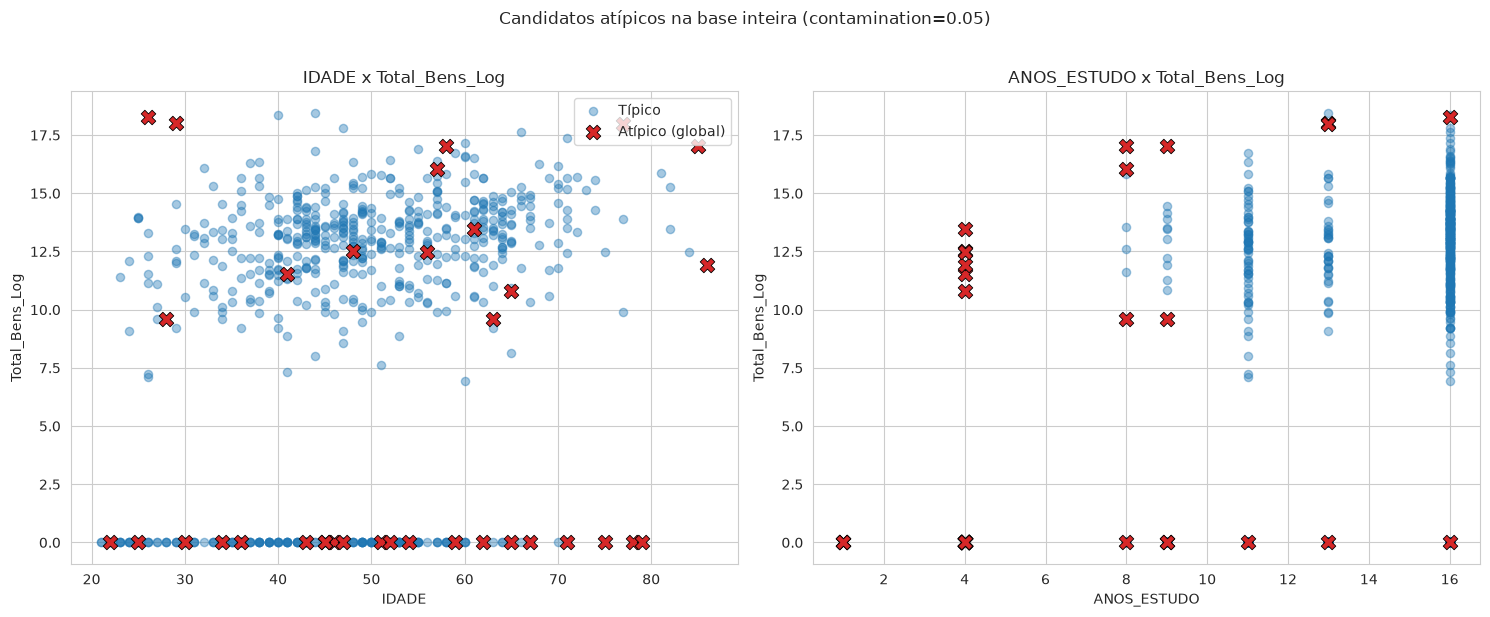

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (x_col, y_col) in zip(axes, [('IDADE', 'Total_Bens_Log'), ('ANOS_ESTUDO', 'Total_Bens_Log')]):
    tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
    atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']
    ax.scatter(tipicos[x_col], tipicos[y_col], c='tab:blue', alpha=0.4, s=35, label='Típico')
    ax.scatter(atipicos[x_col], atipicos[y_col], c='tab:red', marker='X', s=110,
               edgecolor='black', linewidth=0.6, label='Atípico (global)')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} x {y_col}')

axes[0].legend()
plt.suptitle(f'Candidatos atípicos na base inteira (contamination={contamination_global})', y=1.02)
plt.tight_layout()
plt.show()


### O mesmo recorte, em 3D

As duas variáveis de cada vez (painel acima) escondem alguma coisa: dois candidatos podem parecer próximos no plano `IDADE` x `Total_Bens_Log` e estar bem longe um do outro na terceira variável (`ANOS_ESTUDO`). Como o modelo usa as **3 variáveis-driver ao mesmo tempo**, um gráfico 3D interativo mostra isso sem esconder nenhuma dimensão — arrastem pra rotacionar, passem o mouse num ponto pra ver quem é.


In [13]:
cores_iso = {'Típico': '#1f77b4', 'Atípico': '#d62728'}

fig3d = go.Figure()
for status, cor in cores_iso.items():
    sub = df_cluster[df_cluster['anomalia_global'] == status]
    fig3d.add_trace(go.Scatter3d(
        x=sub['IDADE'], y=sub['ANOS_ESTUDO'], z=sub['Total_Bens_Log'],
        mode='markers', name=status,
        marker=dict(
            size=6 if status == 'Típico' else 9,
            color=cor,
            symbol='circle' if status == 'Típico' else 'diamond',
            opacity=0.5 if status == 'Típico' else 0.95,
            line=dict(width=1, color='black'),
        ),
        text=sub['NM_URNA_CANDIDATO'] + ' — ' + sub['cluster'],
        hovertemplate='<b>%{text}</b><br>IDADE=%{x}<br>ANOS_ESTUDO=%{y}<br>Total_Bens_Log=%{z:.2f}<extra></extra>',
    ))

fig3d.update_layout(
    scene=dict(xaxis_title='IDADE', yaxis_title='ANOS_ESTUDO', zaxis_title='Total_Bens_Log'),
    title=f'Candidatos atípicos (visão global) nas 3 variáveis-driver (contamination={contamination_global})',
    height=650, margin=dict(l=0, r=0, b=0, t=40),
)
fig3d.show()


---
## Detecção dentro de cada cluster: quem foge do padrão do próprio grupo?

Treinamos **uma nova floresta somente nos integrantes de cada cluster**. Essa mudança de população define a análise local. Usamos as mesmas linhas de `X`; não é necessário usar `StandardScaler` por grupo para tornar a análise local. Os cortes do Isolation Forest já usam os intervalos das variáveis presentes no treinamento.

Aplicamos `contamination=0.05` por grupo, aproximadamente 5% de seus integrantes. Isso pode sinalizar registros em todos os grupos, mesmo quando são homogêneos. Grupos com menos de dez registros são marcados como **Não avaliado**, pois a análise seria sustentada por poucos pontos.

Scores de florestas distintas não formam uma escala única: não ordene candidatos de grupos diferentes por `score_cluster` para concluir quem é mais anômalo. Examine o ranking e o perfil **dentro de cada grupo**.


In [14]:
contamination_local = 0.05
min_candidatos_local = 10
resultados_cluster = []
modelos_locais = {}

df_cluster['anomalia_cluster'] = 'Não avaliado'
df_cluster['score_cluster'] = np.nan

for letra, nome in NOMES_CLUSTER_BISECTING.items():
    sub_idx = df_cluster.index[df_cluster['cluster_bisecting'] == letra].to_numpy()
    n = len(sub_idx)
    if n < min_candidatos_local:
        resultados_cluster.append({'cluster': letra, 'nome': nome, 'qtd': n,
                                   'qtd_atipicos': 0, 'avaliado': False})
        continue
    X_cluster = X[sub_idx]
    modelo = IsolationForest(contamination=contamination_local,
                             random_state=SEMENTE, n_estimators=200)
    pred = modelo.fit_predict(X_cluster)
    modelos_locais[letra] = modelo
    df_cluster.loc[sub_idx, 'anomalia_cluster'] = np.where(pred == -1, 'Atípico', 'Típico')
    df_cluster.loc[sub_idx, 'score_cluster'] = modelo.decision_function(X_cluster)
    resultados_cluster.append({'cluster': letra, 'nome': nome, 'qtd': n,
                               'qtd_atipicos': int((pred == -1).sum()), 'avaliado': True})

resumo_local = pd.DataFrame(resultados_cluster)
resumo_local['pct_atipicos'] = (100 * resumo_local['qtd_atipicos'] / resumo_local['qtd']).round(1)
display(resumo_local)


,cluster,nome,qtd,qtd_atipicos,avaliado,pct_atipicos
0,A,Adultos com superior e bens,203,11,True,5.4
1,B,Mais velhos com superior e bens,184,10,True,5.4
2,C,Alta escolaridade sem bens declarados,106,6,True,5.7
3,D,Jovens com menor escolaridade e poucos bens,90,5,True,5.6
4,E,Adultos com escolaridade intermediária e bens,75,4,True,5.3
5,F,Mais velhos com menor escolaridade e bens,34,2,True,5.9


In [15]:
for nome in df_cluster['cluster'].unique():
    print(f"--- {nome}: mais atípicos dentro do grupo ---")
    sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == 'Atípico')]
    display(sub.sort_values('score_cluster')[colunas_ficha_anomalia + ['score_cluster']])


--- Mais velhos com superior e bens: mais atípicos dentro do grupo ---


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_cluster
247,90002542624,MAGDA MOFATTO,GO,PL,77,13,62944315.40,B,Mais velhos com superior e bens,-0.154947
443,110002540127,NELSON BARBUDO,MT,PODE,66,13,130000.00,B,Mais velhos com superior e bens,-0.061550
41,70002538516,PROF. DÍDIA,DF,UNIÃO,60,16,1035.84,B,Mais velhos com superior e bens,-0.060189
109,70002543823,RITA BALLOCK,DF,MOBILIZA,70,13,2200000.00,B,Mais velhos com superior e bens,-0.055895
553,110002551937,CARLOS LONGO,MT,AGIR,58,13,7500000.00,B,Mais velhos com superior e bens,-0.047543
90,70002541500,ELIZEU COSTA DO UBER,DF,DC,53,13,250000.00,B,Mais velhos com superior e bens,-0.042398
313,90002543562,PEDRO CANEDO,GO,PRD,77,16,20000.00,B,Mais velhos com superior e bens,-0.035843
167,70002554386,ROBERTO FREIRE,DF,CIDADANIA,84,16,265289.51,B,Mais velhos com superior e bens,-0.024309
544,110002550871,VICTÓRIO GALLI,MT,PP,65,16,3474.40,B,Mais velhos com superior e bens,-0.007076
298,90002543461,FONTES LUCENA,GO,PSOL,60,13,220000.00,B,Mais velhos com superior e bens,-0.000289


--- Adultos com superior e bens: mais atípicos dentro do grupo ---


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_cluster
337,90002547101,FELIPE CECÍLIO,GO,PSDB,26,16,86829450.00,A,Adultos com superior e bens,-0.135602
481,110002547778,JAMILLE CARRASCO,MT,SOLIDARIEDADE,23,16,88189.03,A,Adultos com superior e bens,-0.096532
428,90002554320,CARMEM LUCIA,GO,PSB,41,16,1538.71,A,Adultos com superior e bens,-0.087774
334,90002547098,ELIETE PAIXÃO,GO,PSDB,51,16,2012.58,A,Adultos com superior e bens,-0.087757
111,70002544462,ANA FEROLA,DF,AVANTE,40,16,95000000.00,A,Adultos com superior e bens,-0.085939
526,110002549190,IZALBA DA SAÚDE,MT,REPUBLICANOS,53,16,7250.65,A,Adultos com superior e bens,-0.081220
248,90002542625,RENATO RIBEIRO,GO,PL,47,16,53950216.23,A,Adultos com superior e bens,-0.068486
314,90002543563,JOÃO PEDRO ALMEIDA,GO,SOLIDARIEDADE,32,16,9821369.58,A,Adultos com superior e bens,-0.027206
381,90002548854,MAELLA BETHÂNIA,GO,REPUBLICANOS,29,16,10000.00,A,Adultos com superior e bens,-0.021878
638,120002544956,MATEUS QUADROS,MS,MISSÃO,27,16,15000.00,A,Adultos com superior e bens,-0.002311


--- Alta escolaridade sem bens declarados: mais atípicos dentro do grupo ---


...

,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_cluster
198,90002539159,EDMOTOS,GO,PV,41,4,100000.00,E,Adultos com escolaridade intermediária e bens,-0.027917
603,120002537356,ISA MARCONDES,MS,REPUBLICANOS,48,4,276528.38,E,Adultos com escolaridade intermediária e bens,-0.022373
382,90002549180,FABRÍCIO DA 44,GO,PODE,50,8,7423380.00,E,Adultos com escolaridade intermediária e bens,-0.016942
19,70002537007,ADRIANO AMARAL,DF,PSD,29,13,66757749.04,E,Adultos com escolaridade intermediária e bens,-0.013086


--- Jovens com menor escolaridade e poucos bens: mais atípicos dentro do grupo ---


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_cluster
27,70002537107,MILENA DO MLB,DF,UP,26,11,1404.35,D,Jovens com menor escolaridade e poucos bens,-0.099199
26,70002537106,DURVAL,DF,UP,26,11,1224.11,D,Jovens com menor escolaridade e poucos bens,-0.091706
399,90002550215,PASTOR JUAREZ DA SAÚDE,GO,PDT,67,8,0.00,D,Jovens com menor escolaridade e poucos bens,-0.041614
291,90002543454,BARBARA BOMBOM,GO,PSOL,34,1,0.00,D,Jovens com menor escolaridade e poucos bens,-0.037712
561,110002552089,LUSIMAR DA CANAÃ,MT,DC,47,1,0.00,D,Jovens com menor escolaridade e poucos bens,-0.001141


--- Mais velhos com menor escolaridade e bens: mais atípicos dentro do grupo ---


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_cluster
668,120002550718,CHICO SÁ,MS,AVANTE,86,4,150000.00,F,Mais velhos com menor escolaridade e bens,-0.058210
328,90002547092,ADAIR HENRIQUES VOVÔ DO JEEP,GO,PSDB,85,8,25041060.33,F,Mais velhos com menor escolaridade e bens,-0.053437


### O mesmo recorte, em 3D — filtrando por cluster

Escolha um dos seis grupos no menu. Os pontos vermelhos foram sinalizados pelo modelo treinado **dentro daquele grupo**. Os eixos ficam fixos entre os grupos para comparar a posição no espaço original. O gráfico é descritivo; o score aparece na lista de cada grupo.


In [16]:
nomes_bisecting_ordenados = list(NOMES_CLUSTER_BISECTING.values())
n_status = len(cores_iso)  # 'Típico' e 'Atípico', mesmas cores do gráfico 3D global

fig3d_cluster = go.Figure()
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    for status, cor in cores_iso.items():
        sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == status)]
        fig3d_cluster.add_trace(go.Scatter3d(
            x=sub['IDADE'], y=sub['ANOS_ESTUDO'], z=sub['Total_Bens_Log'],
            mode='markers', name=status,
            marker=dict(
                size=6 if status == 'Típico' else 9,
                color=cor,
                symbol='circle' if status == 'Típico' else 'diamond',
                opacity=0.55 if status == 'Típico' else 0.95,
                line=dict(width=1, color='black'),
            ),
            text=sub['NM_URNA_CANDIDATO'],
            hovertemplate='<b>%{text}</b><br>IDADE=%{x}<br>ANOS_ESTUDO=%{y}<br>Total_Bens_Log=%{z:.2f}<extra></extra>',
            visible=(idx_cluster == 0),       # só o primeiro cluster começa visível
            legendgroup=status,
            showlegend=True,  # só os traços do grupo selecionado ficam visíveis
        ))

# um botão por cluster no menu suspenso — cada um liga só os 2 traços (Típico/Atípico) daquele cluster
botoes_cluster = []
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    visibilidade = [False] * (len(nomes_bisecting_ordenados) * n_status)
    for j in range(n_status):
        visibilidade[idx_cluster * n_status + j] = True
    botoes_cluster.append(dict(
        label=nome, method='update',
        args=[{'visible': visibilidade}, {'title': f'Atípicos dentro do cluster: {nome}'}],
    ))

fig3d_cluster.update_layout(
    scene=dict(
        xaxis_title='IDADE', yaxis_title='ANOS_ESTUDO', zaxis_title='Total_Bens_Log',
        xaxis=dict(range=[df_cluster['IDADE'].min() - 2, df_cluster['IDADE'].max() + 2]),
        yaxis=dict(range=[df_cluster['ANOS_ESTUDO'].min() - 1, df_cluster['ANOS_ESTUDO'].max() + 1]),
        zaxis=dict(range=[df_cluster['Total_Bens_Log'].min() - 0.5, df_cluster['Total_Bens_Log'].max() + 0.5]),
    ),
    updatemenus=[dict(active=0, buttons=botoes_cluster, x=0.02, y=1.05, xanchor='left')],
    title=f'Atípicos dentro do cluster: {nomes_bisecting_ordenados[0]}',
    height=650, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d_cluster.show()


### Comparando: global vs. dentro do cluster

Há quatro combinações para os candidatos avaliados: atípico nos dois modelos, somente no global, somente no local ou típico nos dois. A concordância é entre dois modelos usando as mesmas variáveis; não é confirmação de irregularidade.

Observe especialmente os casos **típicos globalmente e atípicos dentro do grupo**. Ordenamos a lista por grupo e, depois, pelo score local; não comparamos diretamente scores locais entre grupos.


In [17]:
tabela_comparacao = pd.crosstab(df_cluster['anomalia_global'], df_cluster['anomalia_cluster'])
tabela_comparacao.index.name = 'anomalia_global \\ anomalia_cluster'
display(tabela_comparacao)

so_no_cluster = df_cluster[(df_cluster['anomalia_global'] == 'Típico') & (df_cluster['anomalia_cluster'] == 'Atípico')]
print(f"\n{len(so_no_cluster)} candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):")
so_no_cluster[colunas_ficha_anomalia + ['score_cluster']].sort_values(['cluster', 'score_cluster'])


anomalia_cluster,Atípico,Típico
anomalia_global \ anomalia_cluster,,
Atípico,14,21
Típico,24,633



24 candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,score_cluster
382,90002549180,FABRÍCIO DA 44,GO,PODE,50,8,7423380.00,E,Adultos com escolaridade intermediária e bens,-0.016942
481,110002547778,JAMILLE CARRASCO,MT,SOLIDARIEDADE,23,16,88189.03,A,Adultos com superior e bens,-0.096532
428,90002554320,CARMEM LUCIA,GO,PSB,41,16,1538.71,A,Adultos com superior e bens,-0.087774
334,90002547098,ELIETE PAIXÃO,GO,PSDB,51,16,2012.58,A,Adultos com superior e bens,-0.087757
111,70002544462,ANA FEROLA,DF,AVANTE,40,16,95000000.00,A,Adultos com superior e bens,-0.085939
526,110002549190,IZALBA DA SAÚDE,MT,REPUBLICANOS,53,16,7250.65,A,Adultos com superior e bens,-0.081220
248,90002542625,RENATO RIBEIRO,GO,PL,47,16,53950216.23,A,Adultos com superior e bens,-0.068486
314,90002543563,JOÃO PEDRO ALMEIDA,GO,SOLIDARIEDADE,32,16,9821369.58,A,Adultos com superior e bens,-0.027206
381,90002548854,MAELLA BETHÂNIA,GO,REPUBLICANOS,29,16,10000.00,A,Adultos com superior e bens,-0.021878
638,120002544956,MATEUS QUADROS,MS,MISSÃO,27,16,15000.00,A,Adultos com superior e bens,-0.002311


## Ficha comparativa: o que diferencia os casos sinalizados?

Para cada candidato atípico em pelo menos um modelo, mostramos suas diferenças em relação à **mediana do próprio grupo**. Esses desvios descrevem o perfil, mas não são contribuições causais ao score da floresta. A diferença de bens está em reais e pode ser influenciada por valores extremos.


In [18]:
medianas_grupo = df_cluster.groupby('cluster_bisecting')[['IDADE', 'ANOS_ESTUDO', 'Total_Bens']].transform('median')
for coluna in ['IDADE', 'ANOS_ESTUDO', 'Total_Bens']:
    df_cluster[f'{coluna}_desvio_mediana_grupo'] = df_cluster[coluna] - medianas_grupo[coluna]

mask_revisao = (df_cluster['anomalia_global'] == 'Atípico') | (df_cluster['anomalia_cluster'] == 'Atípico')
colunas_desvios = [f'{c}_desvio_mediana_grupo' for c in ['IDADE', 'ANOS_ESTUDO', 'Total_Bens']]
ficha_revisao = df_cluster.loc[mask_revisao, colunas_ficha_anomalia + [
    'anomalia_global', 'score_global', 'anomalia_cluster', 'score_cluster',
] + colunas_desvios].sort_values(['cluster_bisecting', 'score_global'])
print(f'{len(ficha_revisao)} candidatos sinalizados por pelo menos um modelo')
display(ficha_revisao.round(3))


59 candidatos sinalizados por pelo menos um modelo


,SQ_CANDIDATO,NM_URNA_CANDIDATO,SG_UF,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,cluster_bisecting,cluster,anomalia_global,score_global,anomalia_cluster,score_cluster,IDADE_desvio_mediana_grupo,ANOS_ESTUDO_desvio_mediana_grupo,Total_Bens_desvio_mediana_grupo
337,90002547101,FELIPE CECÍLIO,GO,PSDB,26,16,86829450.00,A,Adultos com superior e bens,Atípico,-0.032,Atípico,-0.136,-18.0,0.0,86334450.00
111,70002544462,ANA FEROLA,DF,AVANTE,40,16,95000000.00,A,Adultos com superior e bens,Típico,0.034,Atípico,-0.086,-4.0,0.0,94505000.00
481,110002547778,JAMILLE CARRASCO,MT,SOLIDARIEDADE,23,16,88189.03,A,Adultos com superior e bens,Típico,0.044,Atípico,-0.097,-21.0,0.0,-406810.97
638,120002544956,MATEUS QUADROS,MS,MISSÃO,27,16,15000.00,A,Adultos com superior e bens,Típico,0.061,Atípico,-0.002,-17.0,0.0,-480000.00
248,90002542625,RENATO RIBEIRO,GO,PL,47,16,53950216.23,A,Adultos com superior e bens,Típico,0.064,Atípico,-0.068,3.0,0.0,53455216.23
381,90002548854,MAELLA BETHÂNIA,GO,REPUBLICANOS,29,16,10000.00,A,Adultos com superior e bens,Típico,0.070,Atípico,-0.022,-15.0,0.0,-485000.00
428,90002554320,CARMEM LUCIA,GO,PSB,41,16,1538.71,A,Adultos com superior e bens,Típico,0.072,Atípico,-0.088,-3.0,0.0,-493461.29
314,90002543563,JOÃO PEDRO ALMEIDA,GO,SOLIDARIEDADE,32,16,9821369.58,A,Adultos com superior e bens,Típico,0.078,Atípico,-0.027,-12.0,0.0,9326369.58
334,90002547098,ELIETE PAIXÃO,GO,PSDB,51,16,2012.58,A,Adultos com superior e bens,Típico,0.079,Atípico,-0.088,7.0,0.0,-492987.42
98,70002542520,CARLA GEHLEN,DF,PSB,47,16,5308.00,A,Adultos com superior e bens,Típico,0.108,Atípico,-0.000,3.0,0.0,-489692.00


## Exportação opcional

Para salvar a análise, altere `EXPORTAR_RESULTADOS` para `True`. O CSV inclui todos os candidatos da base preparada, seus clusters e os resultados dos modelos. Registros excluídos na preparação estão na tabela `excluidos_preparacao`, sem score de anomalia.


In [ ]:
EXPORTAR_RESULTADOS = False

if EXPORTAR_RESULTADOS:
    from pathlib import Path
    arquivo_resultados = Path('dados') / f'candidatos_{nome_cargo}_{nome_uf}_ANOMALIAS_{ANO_ELEICAO}.csv'
    colunas_exportar = colunas_ficha_anomalia + [
        'anomalia_global', 'score_global', 'anomalia_cluster', 'score_cluster',
    ] + colunas_desvios
    df_cluster[colunas_exportar].to_csv(arquivo_resultados, index=False)
    print(f'Resultados salvos em: {arquivo_resultados}')
else:
    print('Para salvar o CSV, defina EXPORTAR_RESULTADOS = True e execute esta célula.')


Resultados salvos em: dados/candidatos_DEPUTADO_FEDERAL_CENTRO_OESTE_ANOMALIAS_2026.csv


---
## Fechamento

A Fase 4 reúne um score global e uma análise dentro de cada um dos seis perfis da Fase 2. A lista é uma ferramenta de exploração: examine os registros originais, os limites da preparação e a sensibilidade ao limiar. Ser atípico nestas três variáveis não significa erro de cadastro ou irregularidade.

**Exercícios:**
- Alterar `contamination_global` e `contamination_local`, executar as células seguintes e comparar as listas.
- Comparar com Local Outlier Factor, usando a mesma base e explicando sua noção de densidade local.
- Examinar candidatos sinalizados apenas no próprio grupo: quais variáveis destoam de seus colegas?
- Comparar o resultado com uma análise que preserve os candidatos excluídos pelo IQR, explicitando a mudança de população.
